<a href="https://colab.research.google.com/github/bansal1600/EfficientML.ai-Inference-Optimization/blob/main/KMeans-Weight-Quantization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### K-means Weight Quantization Explained

**What is Weight Quantization?**
Weight quantization is a technique used to reduce the memory footprint and computational cost of neural networks by representing their weights with fewer bits (e.g., 8-bit integers instead of 32-bit floats). This can significantly speed up inference and allow large models to run on devices with limited resources.

**Why K-means?**
Traditional quantization often involves uniform spacing of quantization levels. K-means quantization, however, uses a clustering algorithm to find optimal quantization levels (centroids) that minimize the distortion when representing the original weights. This means that weights that are more important or more frequent can have finer-grained representation, leading to potentially better accuracy preservation compared to simple uniform quantization.

**How it works (conceptually):**
1.  **Extract Weights**: Identify the weights (e.g., from linear layers) in your neural network that you want to quantize.
2.  **Reshape**: Flatten these weights into a 1D array.
3.  **Cluster with K-means**: Apply the K-means clustering algorithm to this 1D array. Each cluster centroid will become a quantization level.
4.  **Assign and Replace**: For each original weight, find the closest cluster centroid and replace the original weight with that centroid's value. This effectively maps a range of floating-point values to a smaller set of discrete, clustered values.
5.  **Reconstruct**: Reshape the quantized weights back to their original dimensions and replace them in the model.

This process results in a model where weights are represented by a limited set of learned values, effectively compressing the model.

In [1]:
import torch
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(42)
torch.manual_seed(42)

In [2]:
def kmeans_quantize_weights(weights, n_clusters):
    """
    Applies K-means quantization to a given tensor of weights.

    Args:
        weights (torch.Tensor): The weights to quantize.
        n_clusters (int): The number of quantization levels (K in K-means).

    Returns:
        torch.Tensor: The quantized weights.
        np.ndarray: The cluster centroids (quantization levels).
    """
    # Flatten the weights to a 1D array for K-means
    original_shape = weights.shape
    flat_weights = weights.detach().cpu().numpy().reshape(-1, 1)

    # Apply K-means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(flat_weights)

    # Get the cluster centroids (these are our quantization levels)
    centroids = kmeans.cluster_centers_.flatten()

    # Assign each weight to its closest centroid
    labels = kmeans.predict(flat_weights)
    quantized_flat_weights = centroids[labels]

    # Reshape back to the original dimensions
    quantized_weights = torch.from_numpy(quantized_flat_weights.reshape(original_shape)).to(weights.device).float()

    return quantized_weights, centroids

### Finding the Optimal Number of Clusters (K) using the Elbow Method

The "Elbow Method" is a heuristic used in K-means clustering to determine the optimal number of clusters. It plots the **Within-Cluster Sum of Squares (WCSS)** against the number of clusters (K).

**What is WCSS?**
WCSS (also known as inertia) is the sum of the squared distances between each point and the centroid of its assigned cluster. A smaller WCSS generally means points are closer to their cluster centers, indicating better clustering.

**How the Elbow Method works:**
1.  Run K-means for a range of K values (e.g., from 1 to 10).
2.  For each K, calculate the WCSS.
3.  Plot WCSS against K.
4.  Look for an "elbow" point in the graph. This is the point where the rate of decrease in WCSS significantly changes. Before the elbow, adding more clusters provides substantial benefits in reducing WCSS. After the elbow, the gains diminish, suggesting that adding more clusters does not provide much better modeling of the data's structure. This 'elbow' often represents a good balance between minimizing WCSS and having a reasonable number of clusters.

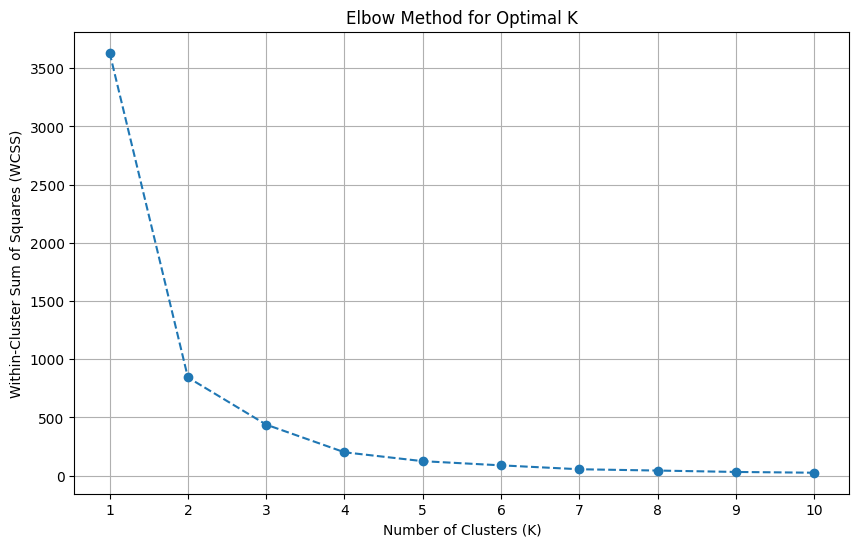

WCSS values for K = 1 to 10: [3632.8125, 843.6082153320312, 438.4989318847656, 200.9127960205078, 124.54507446289062, 88.70828247070312, 55.19371032714844, 43.9823112487793, 31.97535514831543, 25.3492374420166]


In [5]:
# Prepare the flattened weights for WCSS calculation
flat_weights_for_elbow = dummy_weights.detach().cpu().numpy().reshape(-1, 1)

# Calculate WCSS for different numbers of clusters
wcss = []
max_clusters = 10 # You can adjust this range

for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(flat_weights_for_elbow)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_clusters + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.xticks(range(1, max_clusters + 1))
plt.show()

print("WCSS values for K = 1 to 10:", wcss)

#### Interpreting the Elbow Plot

Examine the plot generated above. The "elbow" point is where the curve starts to bend and flatten out. This point often represents a good trade-off. For the `dummy_weights` used in this example, you might observe a clear elbow, or it might be more subtle depending on the data distribution. The `n_clusters` value at this elbow point is often considered the optimal number of clusters for your data, as increasing K beyond this point yields diminishing returns in reducing the within-cluster sum of squares.

### Comparing Compression for Different Numbers of Clusters (K)

--- Comparing Compression ---

K = 2 clusters:
  Number of unique original weights: 32
  Number of unique quantized weights: 2
  Compression Ratio (unique values): 16.00x

K = 4 clusters:
  Number of unique original weights: 32
  Number of unique quantized weights: 4
  Compression Ratio (unique values): 8.00x

K = 8 clusters:
  Number of unique original weights: 32
  Number of unique quantized weights: 8
  Compression Ratio (unique values): 4.00x

K = 16 clusters:
  Number of unique original weights: 32
  Number of unique quantized weights: 16
  Compression Ratio (unique values): 2.00x

K = 32 clusters:
  Number of unique original weights: 32
  Number of unique quantized weights: 32
  Compression Ratio (unique values): 1.00x


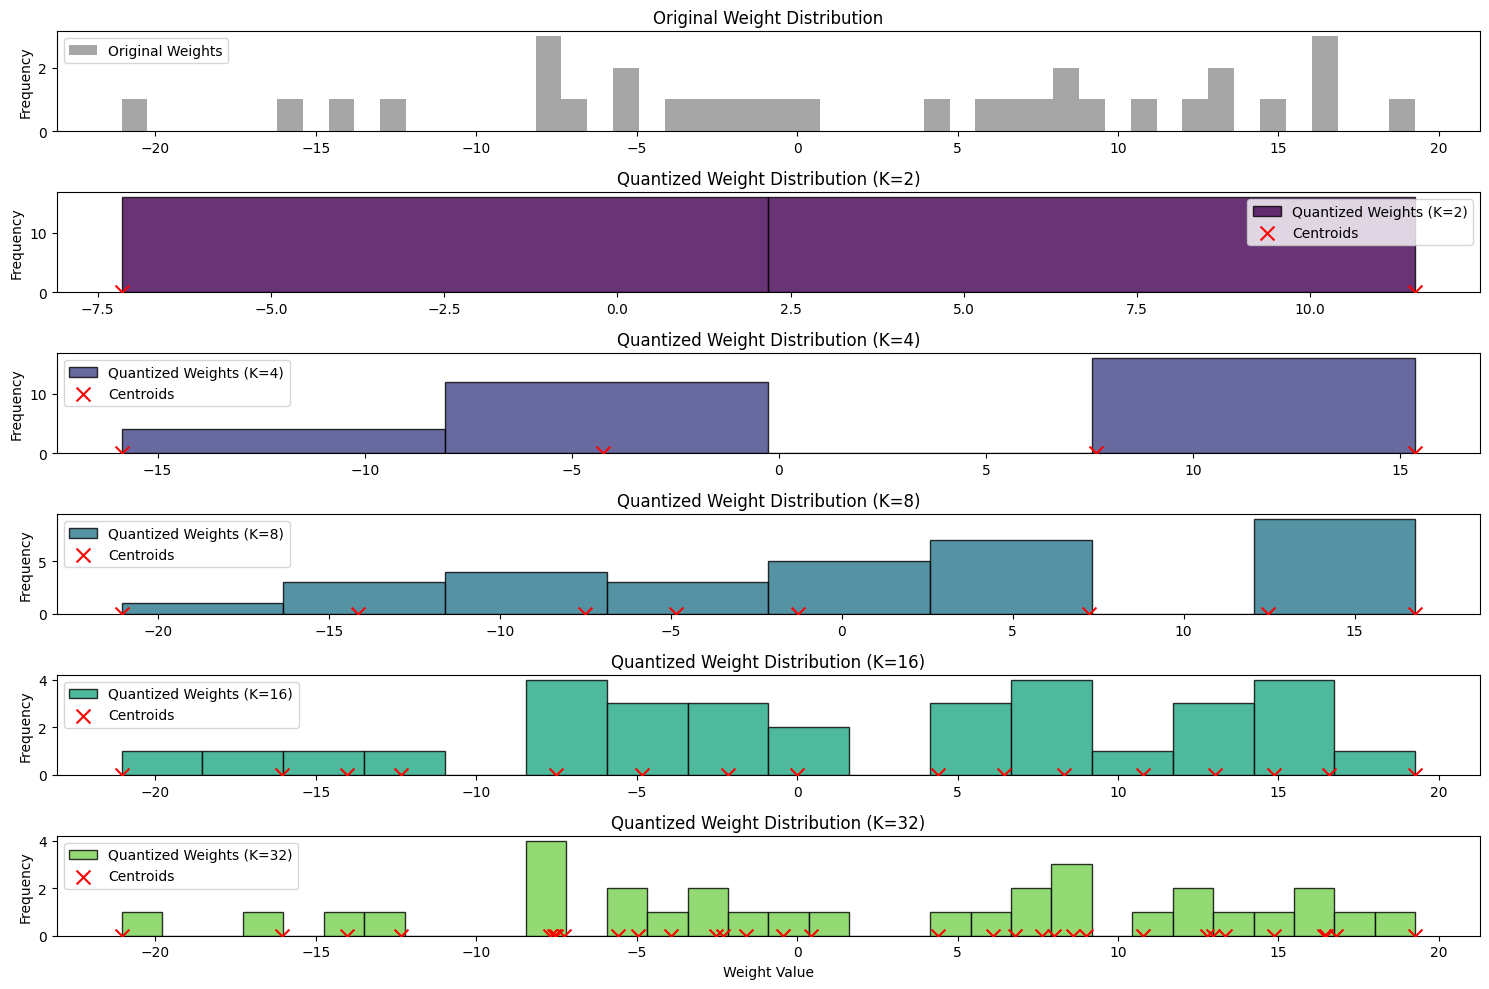

In [4]:
# Define a range of cluster sizes to experiment with
cluster_sizes = [2, 4, 8, 16, 32]

print("--- Comparing Compression ---")

plt.figure(figsize=(15, 10))

# Original weights for comparison
original_flat_weights = dummy_weights.flatten().cpu().numpy()
plt.subplot(len(cluster_sizes) + 1, 1, 1)
plt.hist(original_flat_weights, bins=50, alpha=0.7, color='grey', label='Original Weights')
plt.title('Original Weight Distribution')
plt.ylabel('Frequency')
plt.legend()

for i, k in enumerate(cluster_sizes):
    # Quantize with current K
    quantized_weights_k, centroids_k = kmeans_quantize_weights(dummy_weights, k)

    # Calculate unique values (compression indicator)
    num_unique_original = len(np.unique(original_flat_weights))
    num_unique_quantized = len(np.unique(quantized_weights_k.flatten().cpu().numpy()))

    print(f"\nK = {k} clusters:")
    print(f"  Number of unique original weights: {num_unique_original}")
    print(f"  Number of unique quantized weights: {num_unique_quantized}")
    print(f"  Compression Ratio (unique values): {num_unique_original / num_unique_quantized:.2f}x")

    # Plot the distribution
    plt.subplot(len(cluster_sizes) + 1, 1, i + 2)
    plt.hist(quantized_weights_k.flatten().cpu().numpy(), bins=k, alpha=0.8, label=f'Quantized Weights (K={k})', color=plt.cm.viridis(i/len(cluster_sizes)), edgecolor='black')
    plt.scatter(centroids_k, np.zeros_like(centroids_k), marker='x', color='red', s=100, label='Centroids', zorder=5)
    plt.title(f'Quantized Weight Distribution (K={k})')
    plt.ylabel('Frequency')
    plt.legend()

plt.xlabel('Weight Value')
plt.tight_layout()
plt.show()

Original Dummy Weights:
 tensor([[ 19.2692,  14.8728,   9.0072, -21.0552,   6.7842, -12.3454,  -0.4307,
         -16.0467],
        [ -7.5214,  16.4872,  -3.9248, -14.0361,  -7.2788,  -5.5943,  -7.6884,
           7.6245],
        [ 16.4232,  -1.5960,  -4.9740,   4.3959,  -7.5813,  10.7832,   8.0080,
          16.8062],
        [ 12.7912,  12.9642,   6.1047,  13.3474,  -2.3162,   0.4176,  -2.5158,
           8.5986]])

Quantization Centroids (Levels):
 [-21.05521   -14.142731   -7.5174665  -4.8310213  -1.2882102   7.2175655
  12.471506   16.77172  ]

Quantized Dummy Weights:
 tensor([[ 16.7717,  16.7717,   7.2176, -21.0552,   7.2176, -14.1427,  -1.2882,
         -14.1427],
        [ -7.5175,  16.7717,  -4.8310, -14.1427,  -7.5175,  -4.8310,  -7.5175,
           7.2176],
        [ 16.7717,  -1.2882,  -4.8310,   7.2176,  -7.5175,  12.4715,   7.2176,
          16.7717],
        [ 12.4715,  12.4715,   7.2176,  12.4715,  -1.2882,  -1.2882,  -1.2882,
           7.2176]])


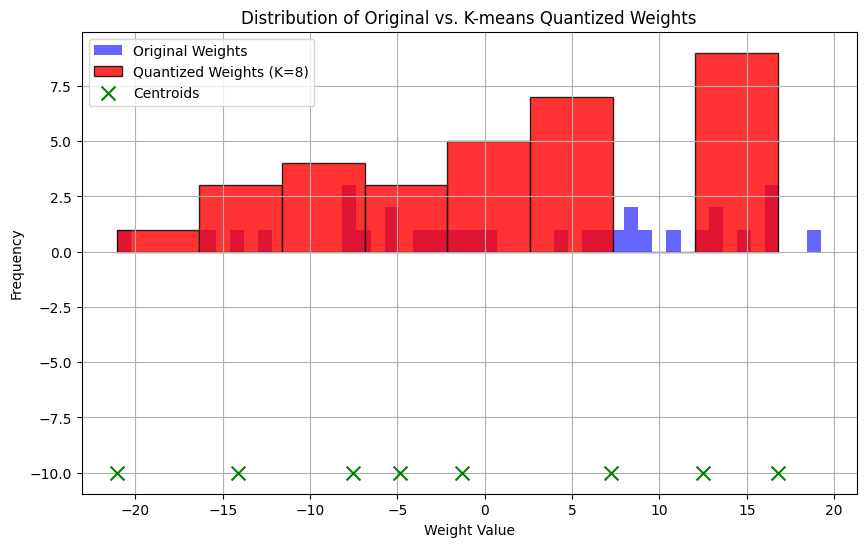

In [3]:
# --- Demonstration with dummy weights ---

# 1. Generate some dummy weights (e.g., from a linear layer)
# Let's imagine a small weight matrix for illustration
dummy_weights = torch.randn(4, 8) * 10 # Values centered around 0

print("Original Dummy Weights:\n", dummy_weights)

# 2. Define the number of quantization levels (e.g., 8 levels for 3-bit representation)
n_clusters = 8

# 3. Quantize the weights
quantized_dummy_weights, centroids = kmeans_quantize_weights(dummy_weights, n_clusters)

print("\nQuantization Centroids (Levels):\n", np.sort(centroids))
print("\nQuantized Dummy Weights:\n", quantized_dummy_weights)

# 4. Visualize the quantization effect
plt.figure(figsize=(10, 6))
plt.hist(dummy_weights.flatten().cpu().numpy(), bins=50, alpha=0.6, label='Original Weights', color='blue')
plt.hist(quantized_dummy_weights.flatten().cpu().numpy(), bins=n_clusters, alpha=0.8, label=f'Quantized Weights (K={n_clusters})', color='red', edgecolor='black')
plt.scatter(centroids, np.zeros_like(centroids) - 10, marker='x', color='green', s=100, label='Centroids', zorder=5)
plt.title('Distribution of Original vs. K-means Quantized Weights')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

### Applying K-means Quantization to a GPT-2 Model

To apply this to a GPT-2 model (or any Transformer model from Hugging Face `transformers` library), you would generally follow these steps:

1.  **Load the Model**: Load your pre-trained GPT-2 model using `transformers`.
    ```python
    from transformers import AutoModelForCausalLM, AutoTokenizer

    model_name = "gpt2"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    ```

2.  **Identify Quantizable Layers**: Typically, `torch.nn.Linear` layers (which represent the weight matrices in attention mechanisms and feed-forward networks) are the primary candidates for weight quantization. Embedding layers might also be considered.

3.  **Iterate and Quantize**: Loop through all the linear layers in the model. For each layer, extract its `weight` tensor, apply the `kmeans_quantize_weights` function, and then replace the layer's `weight` with the newly quantized tensor.
    ```python
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            print(f"Quantizing weights for layer: {name}")
            original_weights = module.weight.data
            quantized_weights, _ = kmeans_quantize_weights(original_weights, n_clusters=8) # Choose your desired K
            module.weight.data = quantized_weights
    ```

4.  **(Optional) Save and Load Quantized Model**: After quantization, you can save the modified model. When loading it back, ensure it correctly uses the quantized weights. For inference, you might want to use a specialized backend (like ONNX Runtime) that can leverage the reduced precision.

**Important Considerations for GPT-2:**

*   **Impact on Accuracy**: Quantization inherently introduces some error. The key is to find a balance between compression and accuracy. You'll need to evaluate the model's performance (e.g., perplexity, downstream task metrics) after quantization.
*   **Number of Clusters (K)**: The choice of `n_clusters` (K) is crucial. A smaller K means more compression but potentially higher accuracy loss. Common values are 4, 8, 16, or 32, corresponding to 2-bit, 3-bit, 4-bit, or 5-bit representation respectively.
*   **Fine-tuning**: Sometimes, quantizing a model can degrade its performance. Quantization-aware training (QAT) or fine-tuning the quantized model can help recover lost accuracy.
*   **Hardware Support**: The benefits of quantization are fully realized when deployed on hardware that efficiently supports lower precision arithmetic (e.g., integer operations).